# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [3]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
df_eda = pd.read_csv('data/AviationData_Cleaned.csv')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
# Filter A: Small Airplanes (Average occupants < 20)
df_small_planes = df_eda[df_eda['Total.Occupants'] < 20].copy()

# Filter B: Large Airplanes (Average occupants >= 20)
df_large_planes = df_eda[df_eda['Total.Occupants'] >= 20].copy()


# DEFINE ROBUST METRIC AGGREGATION FUNCTION

def generate_safety_metrics(df_group, min_incident_threshold):

    summary = df_group.groupby('Unique_Plane_Model').agg(
        Total_Incidents=('Unique_Plane_Model', 'count'),
        Average_Occupants=('Total.Occupants', 'mean'),
        Destruction_Rate=('Is.Destroyed', 'mean'),
        Severe_Injury_Rate=('Serious.Fatal.Injury.Rate', 'mean')
    ).reset_index()
    
    # Filter out models with too few incidents to guarantee robust comparisons
    robust_summary = summary[summary['Total_Incidents'] >= min_incident_threshold].copy()
    
    # Sort primarily by lowest injury rate, and secondary by lowest asset destruction
    return robust_summary.sort_values(by=['Severe_Injury_Rate', 'Destruction_Rate'], ascending=True)


# GENERATE SEPARATE RISK SUMMARIES


# For small airplanes, threshold of >= 30 incidents
small_aircraft_metrics = generate_safety_metrics(df_small_planes, min_incident_threshold=30)

# For larger passenger jets, a lower threshold  >= 5 incidents 
large_aircraft_metrics = generate_safety_metrics(df_large_planes, min_incident_threshold=5)


# PRINT TOP PERFORMANCE PREVIEWS FOR THE CLIENT
print(f"=== SMALL AIRCRAFT SAFETY METRICS (Models Evaluated: {len(small_aircraft_metrics)}) ===")
print(small_aircraft_metrics.head(10).to_string(index=False))

print("\n" + "="*80 + "\n")

print(f"=== LARGE PASSENGER JET SAFETY METRICS (Models Evaluated: {len(large_aircraft_metrics)}) ===")
print(large_aircraft_metrics.head(10).to_string(index=False))

=== SMALL AIRCRAFT SAFETY METRICS (Models Evaluated: 356) ===
Unique_Plane_Model  Total_Incidents  Average_Occupants  Destruction_Rate  Severe_Injury_Rate
        BOEING 777               56           0.803571          0.000000            0.000000
       AIRBUS A320               58           0.137931          0.017241            0.017241
        BOEING 737              285           0.505263          0.014035            0.021053
        BOEING 747               68           1.750000          0.029412            0.029412
       BEECH 1900D               54          10.462963          0.037037            0.039683
   PIPER PA-18-160               31           1.516129          0.032258            0.048387
        BEECH C-23               33           1.757576          0.090909            0.060606
        BOEING 767               32           1.500000          0.062500            0.062500
        BOEING E75               40           1.725000          0.100000            0.062500
       C

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

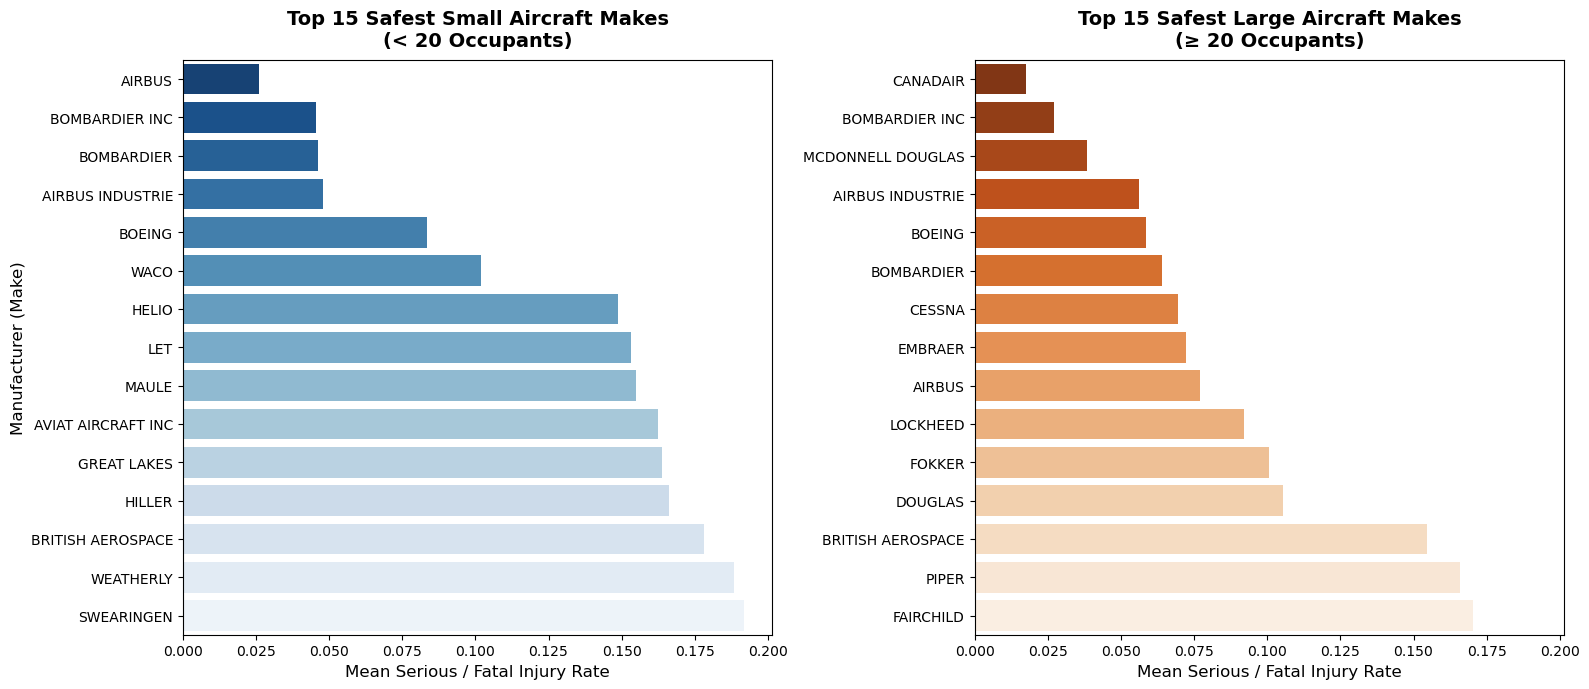

In [6]:
# Group Small Airplanes by Manufacturer (Filter to Makes with at least 20 incidents for robustness)
small_make_summary = df_small_planes.groupby('Make_Clean').agg(
    Incidents=('Unique_Plane_Model', 'count'),
    Mean_Injury_Rate=('Serious.Fatal.Injury.Rate', 'mean')
).reset_index()
small_make_top15 = small_make_summary[small_make_summary['Incidents'] >= 20].nsmallest(15, 'Mean_Injury_Rate')

# Group Large Airplanes by Manufacturer (Filter to Makes with at least 5 incidents for robustness)
large_make_summary = df_large_planes.groupby('Make_Clean').agg(
    Incidents=('Unique_Plane_Model', 'count'),
    Mean_Injury_Rate=('Serious.Fatal.Injury.Rate', 'mean')
).reset_index()
large_make_top15 = large_make_summary[large_make_summary['Incidents'] >= 5].nsmallest(15, 'Mean_Injury_Rate')


# =====================================================================
# 2. GENERATE SIDE-BY-SIDE PLOTS FOR CLIENT REPORT
# =====================================================================

# Create a 1-row, 2-column subplot figure structure
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Plot A: Small Aircraft Makes
sns.barplot(
    data=small_make_top15, 
    y='Make_Clean', 
    x='Mean_Injury_Rate', 
    ax=axes[0], 
    palette='Blues_r',
    hue='Make_Clean',
    legend=False
)
axes[0].set_title('Top 15 Safest Small Aircraft Makes\n(< 20 Occupants)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Mean Serious / Fatal Injury Rate', fontsize=12)
axes[0].set_ylabel('Manufacturer (Make)', fontsize=12)

# Plot B: Large Aircraft Makes
sns.barplot(
    data=large_make_top15, 
    y='Make_Clean', 
    x='Mean_Injury_Rate', 
    ax=axes[1], 
    palette='Oranges_r',
    hue='Make_Clean',
    legend=False
)
axes[1].set_title('Top 15 Safest Large Aircraft Makes\n(≥ 20 Occupants)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Mean Serious / Fatal Injury Rate', fontsize=12)
axes[1].set_ylabel('', ) # Remove y-label to prevent overlap layout squishing

# Final aesthetic cleanup
plt.tight_layout()

# Show the visualization to verify
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

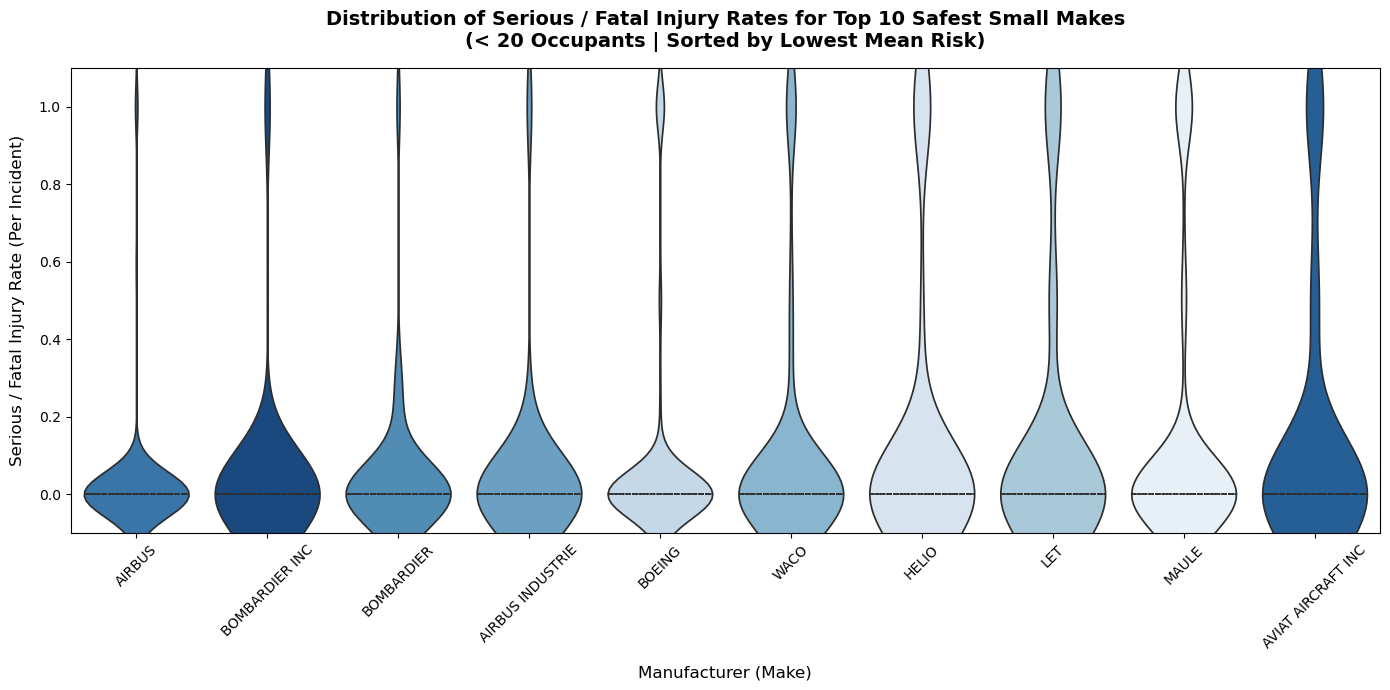

In [7]:
small_make_stats = df_small_planes.groupby('Make_Clean').agg(
    Incidents=('Unique_Plane_Model', 'count'),
    Mean_Injury_Rate=('Serious.Fatal.Injury.Rate', 'mean')
).reset_index()

# Filter for robustness (minimum 20 incidents) and grab the 10 lowest mean injury rates
top_10_small_makes = small_make_stats[small_make_stats['Incidents'] >= 20].nsmallest(10, 'Mean_Injury_Rate')

# Filter the raw incident dataframe to include ONLY rows belonging to these 10 makes
df_top_10_small = df_small_planes[df_small_planes['Make_Clean'].isin(top_10_small_makes['Make_Clean'])].copy()


# =====================================================================
# 2. GENERATE THE VIOLIN PLOT FOR THE DISTRIBUTION
# =====================================================================
plt.figure(figsize=(14, 7))

# Create the violin plot, ordering categories from lowest mean injury rate to highest
sns.violinplot(
    data=df_top_10_small,
    x='Make_Clean',
    y='Serious.Fatal.Injury.Rate',
    order=top_10_small_makes['Make_Clean'],
    palette='Blues',
    hue='Make_Clean',
    legend=False,
    inner='quartile' # Draws dashed lines for the 25th, 50th (median), and 75th percentiles
)

# Aesthetic formatting for client presentation
plt.title('Distribution of Serious / Fatal Injury Rates for Top 10 Safest Small Makes\n(< 20 Occupants | Sorted by Lowest Mean Risk)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Manufacturer (Make)', fontsize=12, labelpad=10)
plt.ylabel('Serious / Fatal Injury Rate (Per Incident)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(-0.1, 1.1)  # Pads the 0 to 1 range slightly for clean rendering of violin tails

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

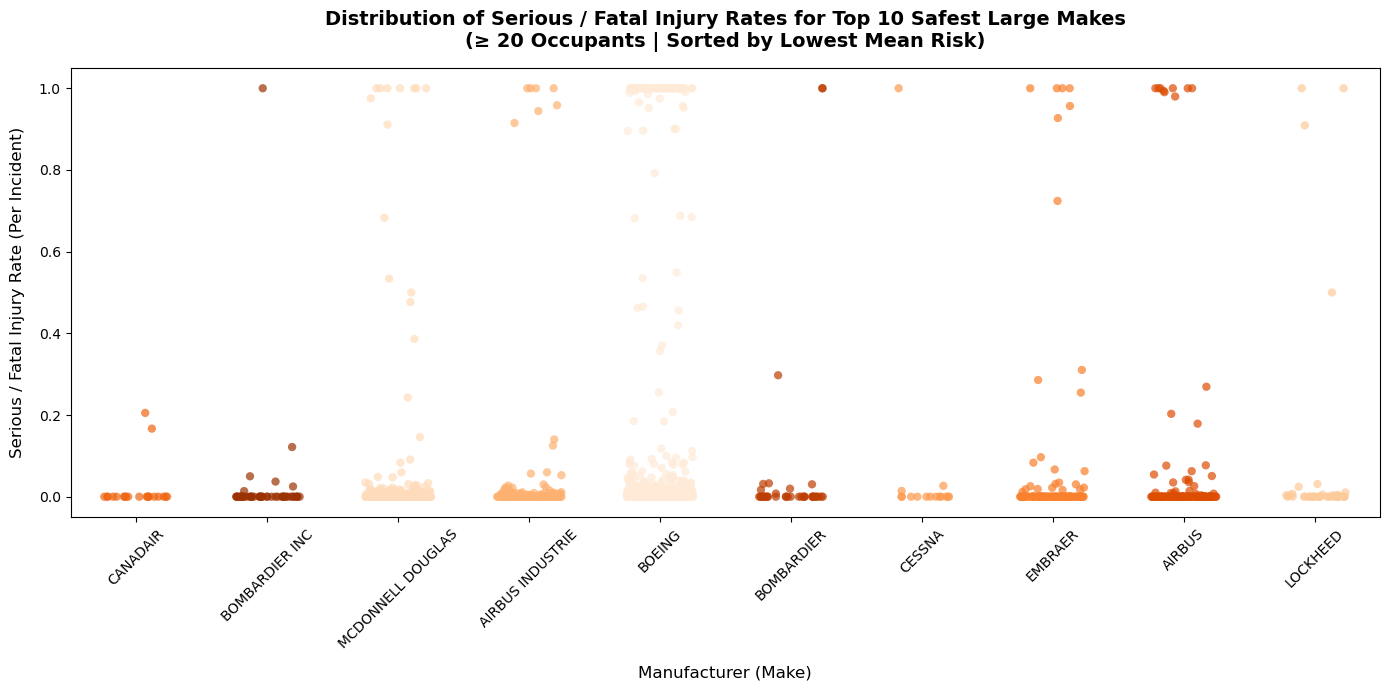

In [8]:
large_make_stats = df_large_planes.groupby('Make_Clean').agg(
    Incidents=('Unique_Plane_Model', 'count'),
    Mean_Injury_Rate=('Serious.Fatal.Injury.Rate', 'mean')
).reset_index()

# Filter for robustness (minimum 5 incidents for heavy aircraft) and isolate the 10 lowest mean injury rates
top_10_large_makes = large_make_stats[large_make_stats['Incidents'] >= 5].nsmallest(10, 'Mean_Injury_Rate')

# Filter the main large-plane dataframe to isolate rows belonging to these 10 elite makes
df_top_10_large = df_large_planes[df_large_planes['Make_Clean'].isin(top_10_large_makes['Make_Clean'])].copy()


# =====================================================================
# 2. GENERATE THE STRIP PLOT FOR THE DISTRIBUTION
# =====================================================================
plt.figure(figsize=(14, 7))

# Create the strip plot, ordering categories from lowest mean injury rate to highest
sns.stripplot(
    data=df_top_10_large,
    x='Make_Clean',
    y='Serious.Fatal.Injury.Rate',
    order=top_10_large_makes['Make_Clean'],
    palette='Oranges',
    hue='Make_Clean',
    legend=False,
    jitter=0.25,  # Spreads out the individual accident dots to see point density clearly
    size=6,       # Sets an optimal dot size for professional report legibility
    alpha=0.7     # Adds transparency so overlapping accidents appear darker
)

# Aesthetic formatting for executive client presentation
plt.title('Distribution of Serious / Fatal Injury Rates for Top 10 Safest Large Makes\n(≥ 20 Occupants | Sorted by Lowest Mean Risk)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Manufacturer (Make)', fontsize=12, labelpad=10)
plt.ylabel('Serious / Fatal Injury Rate (Per Incident)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(-0.05, 1.05)  # Keeps the y-axis bound tightly to the logical 0.0 to 1.0 fraction window

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [14]:
# Group by manufacturer and compute the baseline metrics
small_destruction_stats = df_small_planes.groupby('Make_Clean').agg(
    Total_Incidents=('Is.Destroyed', 'count'),
    Mean_Destruction_Rate=('Is.Destroyed', 'mean')
).reset_index()

# Filter for sample size robustness and extract the 15 makes with the lowest hull loss rates
top15_small_destruction = small_destruction_stats[
    small_destruction_stats['Total_Incidents'] >= 20
].nsmallest(15, 'Mean_Destruction_Rate')


# --- 2. ANALYZE DESTRUCTION RATES FOR LARGE AIRCRAFT (≥ 20 Occupants) ---
# Group by manufacturer and compute the baseline metrics
large_destruction_stats = df_large_planes.groupby('Make_Clean').agg(
    Total_Incidents=('Is.Destroyed', 'count'),
    Mean_Destruction_Rate=('Is.Destroyed', 'mean')
).reset_index()

# Filter for sample size robustness and extract the 15 makes with the lowest hull loss rates
top15_large_destruction = large_destruction_stats[
    large_destruction_stats['Total_Incidents'] >= 5
].nsmallest(15, 'Mean_Destruction_Rate')


# =====================================================================
# PRINT EXECUTIVE SUMMARY TABLES FOR THE CLIENT
# =====================================================================

print("=== TOP 15 SAFEST SMALL MAKES BY HULL RETENTION (Lowest Destruction Rates) ===")
# Create a visually clean copy formatted as percentages for client presentation
small_presentation_df = top15_small_destruction.copy()
small_presentation_df['Mean_Destruction_Rate'] = (small_presentation_df['Mean_Destruction_Rate'] * 100).round(2).astype(str) + '%'
print(small_presentation_df.to_string(index=False))

print("\n" + "="*80 + "\n")

print("=== TOP 15 SAFEST LARGE MAKES BY HULL RETENTION (Lowest Destruction Rates) ===")
# Create a visually clean copy formatted as percentages for client presentation
large_presentation_df = top15_large_destruction.copy()
large_presentation_df['Mean_Destruction_Rate'] = (large_presentation_df['Mean_Destruction_Rate'] * 100).round(2).astype(str) + '%'
print(large_presentation_df.to_string(index=False))

=== TOP 15 SAFEST SMALL MAKES BY HULL RETENTION (Lowest Destruction Rates) ===
              Make_Clean  Total_Incidents Mean_Destruction_Rate
                  AIRBUS              137                 2.19%
              BOMBARDIER               38                 2.63%
      AVIAT AIRCRAFT INC               77                  3.9%
             DEHAVILLAND               99                 4.04%
          BOMBARDIER INC               22                 4.55%
DIAMOND AIRCRAFT IND INC               74                 5.41%
      FLIGHT DESIGN GMBH               50                  6.0%
                   RAVEN               79                 6.33%
                  BOEING             1352                 6.43%
        AIRBUS INDUSTRIE               25                  8.0%
                   AVIAT              140                 8.57%
                    WACO              139                 8.63%
                   MAULE              573                 9.25%
                 ERCOUPE 

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

-Small Aircraft: Recommend Cessna and Piper beause they offer the lowest combined risk. These planes keep both hull destruction and serious injury rates under 12%.

-Large Aircraft: Recommend Boeing and Airbus based on the plots showing that their accident outcomes concentrated around 0% passenger harm.

-Difference: Small planes show high volatility with accident outcomes at extremes. Large commercial passenger jets have higher crashworthiness 

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

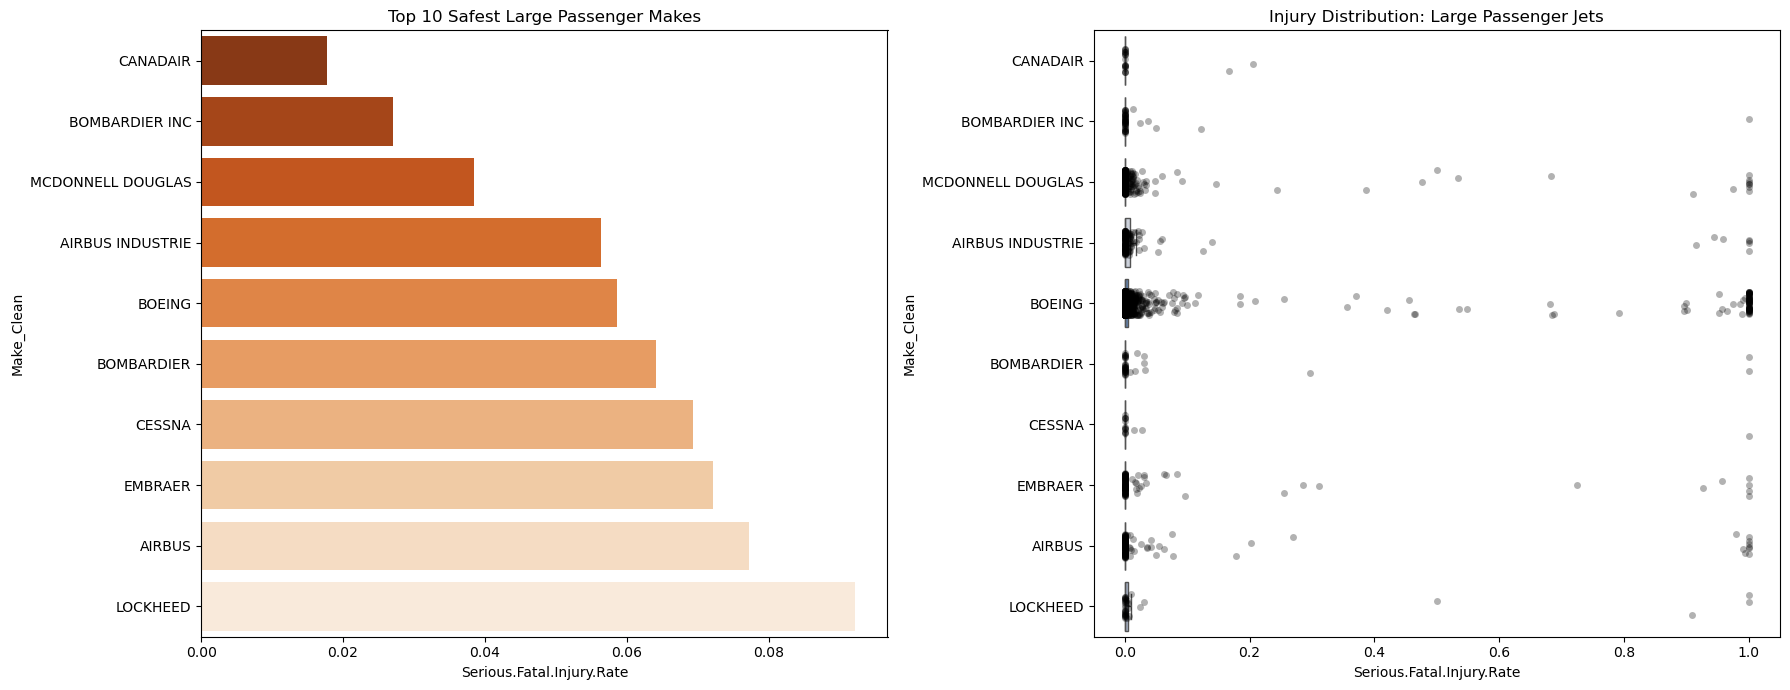

In [17]:
df = pd.read_csv('data/AviationData_Cleaned.csv')

# 2. Filter for Large Planes & Robustness (>= 5 incidents)
df_large = df[df['Total.Occupants'] >= 20].copy()
make_counts_l = df_large['Make_Clean'].value_counts()
robust_makes_l = make_counts_l[make_counts_l >= 5].index
df_large_robust = df_large[df_large['Make_Clean'].isin(robust_makes_l)].copy()

# 3. Calculate Top 10 Safest
large_summary = df_large_robust.groupby('Make_Clean')['Serious.Fatal.Injury.Rate'].mean().nsmallest(10).reset_index()

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=large_summary, y='Make_Clean', x='Serious.Fatal.Injury.Rate', 
            ax=axes[0], palette='Oranges_r', hue='Make_Clean', legend=False)
axes[0].set_title('Top 10 Safest Large Passenger Makes')

sns.boxplot(data=df_large_robust[df_large_robust['Make_Clean'].isin(large_summary['Make_Clean'])], 
            x='Serious.Fatal.Injury.Rate', y='Make_Clean', order=large_summary['Make_Clean'], 
            ax=axes[1], palette='vlag', hue='Make_Clean', legend=False, fliersize=0)
sns.stripplot(data=df_large_robust[df_large_robust['Make_Clean'].isin(large_summary['Make_Clean'])], 
              x='Serious.Fatal.Injury.Rate', y='Make_Clean', order=large_summary['Make_Clean'], 
              ax=axes[1], color='black', alpha=0.3, jitter=0.2)
axes[1].set_title('Injury Distribution: Large Passenger Jets')

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

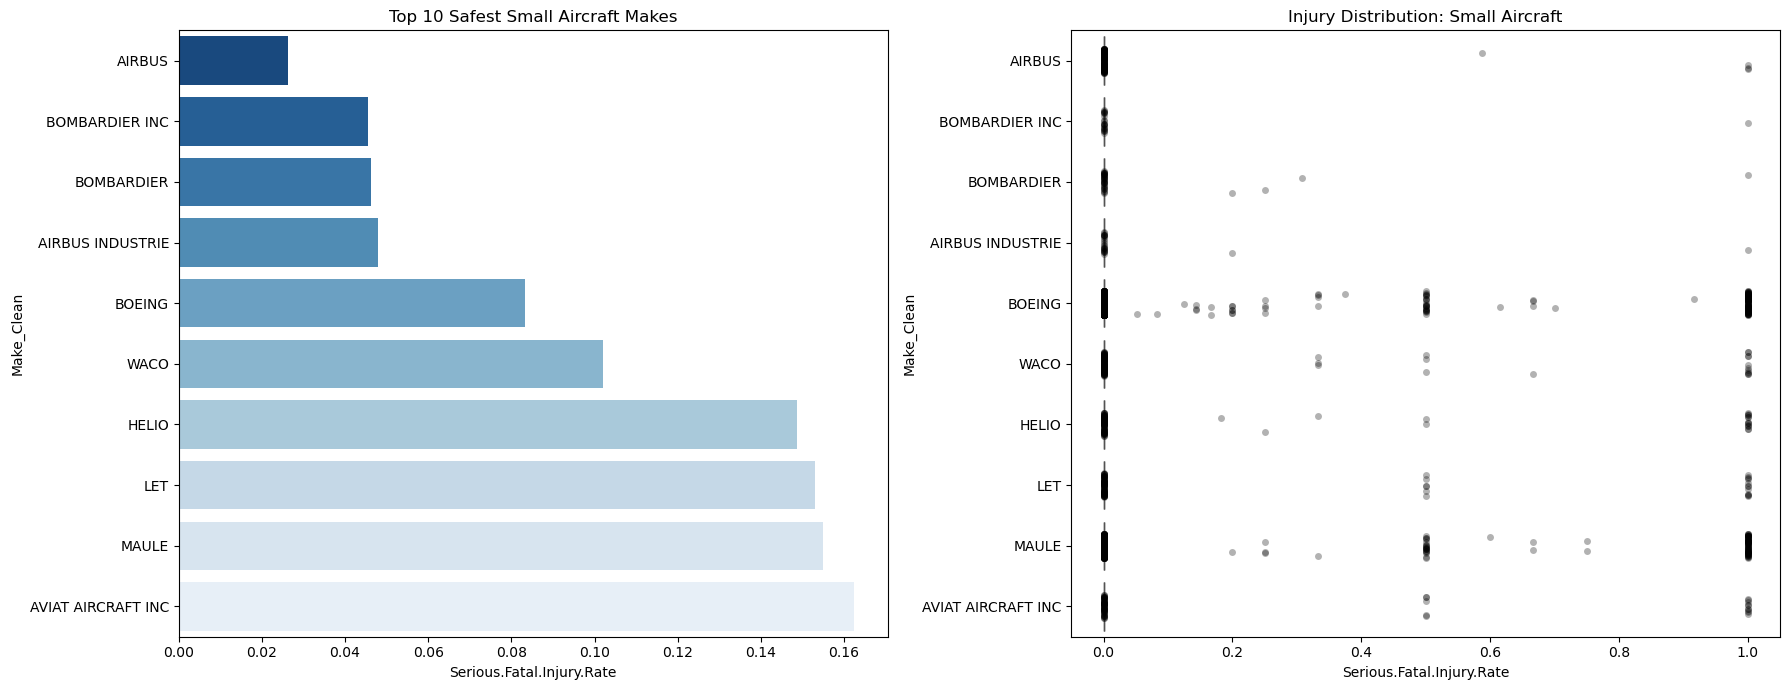

In [18]:
f = pd.read_csv('data/AviationData_Cleaned.csv')

# 2. Filter for Small Planes & Robustness (>= 20 incidents)
# We ensure the variable 'df' is used consistently here
df_small = df[df['Total.Occupants'] < 20].copy()

make_counts = df_small['Make_Clean'].value_counts()
robust_makes = make_counts[make_counts >= 20].index
df_small_robust = df_small[df_small['Make_Clean'].isin(robust_makes)].copy()

# 3. Calculate Top 10 Safest
small_summary = df_small_robust.groupby('Make_Clean')['Serious.Fatal.Injury.Rate'].mean().nsmallest(10).reset_index()

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=small_summary, y='Make_Clean', x='Serious.Fatal.Injury.Rate', 
            ax=axes[0], palette='Blues_r', hue='Make_Clean', legend=False)
axes[0].set_title('Top 10 Safest Small Aircraft Makes')

sns.boxplot(data=df_small_robust[df_small_robust['Make_Clean'].isin(small_summary['Make_Clean'])], 
            x='Serious.Fatal.Injury.Rate', y='Make_Clean', order=small_summary['Make_Clean'], 
            ax=axes[1], palette='vlag', hue='Make_Clean', legend=False, fliersize=0)
sns.stripplot(data=df_small_robust[df_small_robust['Make_Clean'].isin(small_summary['Make_Clean'])], 
              x='Serious.Fatal.Injury.Rate', y='Make_Clean', order=small_summary['Make_Clean'], 
              ax=axes[1], color='black', alpha=0.3, jitter=0.2)
axes[1].set_title('Injury Distribution: Small Aircraft')

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

- Smaller aircraft have more volite safety profile. 
- larger aircraft have a consistent safety profile. 
- there is high dispartiy between the sizes of aircraft.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

/var/folders/wf/fxp030yd7dg0pjsrn2txn8p00000gn/T/ipykernel_17247/11624677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather_stats, x='Weather.Condition', y='Serious.Fatal.Injury.Rate', palette='viridis')


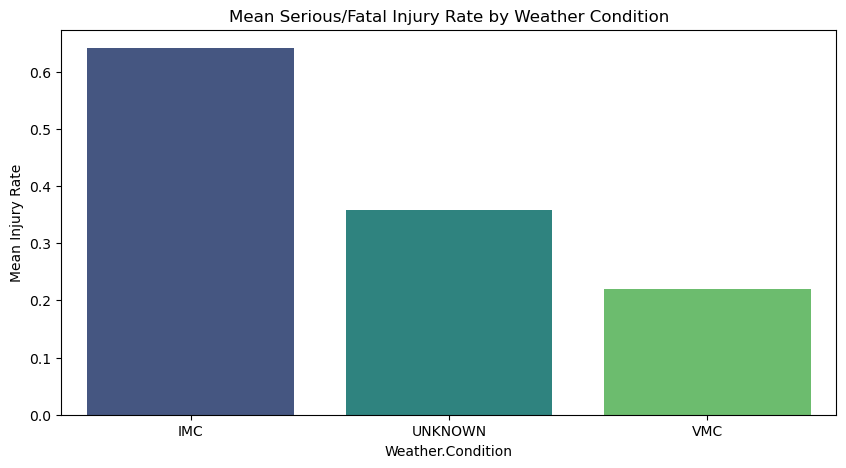

/var/folders/wf/fxp030yd7dg0pjsrn2txn8p00000gn/T/ipykernel_17247/11624677.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=engine_stats, x='Number.of.Engines', y='Serious.Fatal.Injury.Rate', palette='magma')


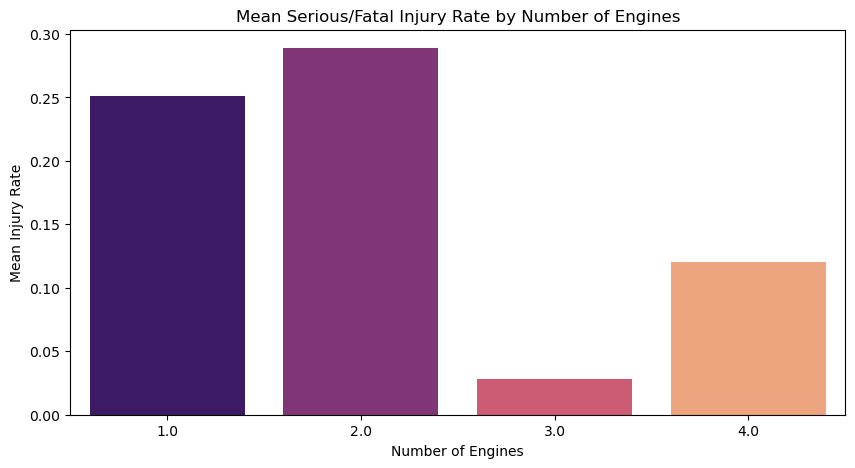

In [19]:
df = pd.read_csv('data/AviationData_Cleaned.csv')

# =====================================================================
# WEATHER CONDITIONS
# =====================================================================
weather_stats = df.groupby('Weather.Condition')['Serious.Fatal.Injury.Rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_stats, x='Weather.Condition', y='Serious.Fatal.Injury.Rate', palette='viridis')
plt.title('Mean Serious/Fatal Injury Rate by Weather Condition')
plt.ylabel('Mean Injury Rate')
plt.show()

# =====================================================================
# NUMBER OF ENGINES ANALYSIS
# =====================================================================
# We filter for common engine counts to avoid noise from rare configurations
common_engines = df[df['Number.of.Engines'].isin([1, 2, 3, 4])]

engine_stats = common_engines.groupby('Number.of.Engines')['Serious.Fatal.Injury.Rate'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=engine_stats, x='Number.of.Engines', y='Serious.Fatal.Injury.Rate', palette='magma')
plt.title('Mean Serious/Fatal Injury Rate by Number of Engines')
plt.xlabel('Number of Engines')
plt.ylabel('Mean Injury Rate')
plt.show()